# PEFT

Сегодня LLM становятся незаменимым инструментом как для полноценного решения продуктовых задач, так и на промежуточных этапах, например, генерация разметки или создание синтетических датасетов. Обучение и дообучение таких моделей может быть ресурсозатратным, поэтому на зачастую полезно использовать Parameter-Efficient Fine-Tuning, PEFT.

PEFT позволяет адаптировать крупные языковые модели под конкретные задачи, внося минимальные изменения в архитектуру и обучаясь на сравнительно небольшом объёме данных. Ключевые методы – такие как адаптеры, LoRA или DoRA – демонстрируют высокую эффективность, позволяя достичь конкурентоспособной точности при низких затратах на вычислительные мощности.

Представьте, что ваша задача – определить тональность твитов. Твиты – короткие, насыщенные эмоциями и часто саркастичные сообщения, где традиционные модели могут давать сбои из-за неформального стиля и ограниченного контекста. Используя PEFT, вы можете донастроить LLM под особенности твиттер-лексикона, адаптируя модель на небольшом, но репрезентативном наборе данных.

## Импортируем зависимости

In [ ]:
%pip install --quiet datasets bitsandbytes trl



In [ ]:
import gc
import os
import random
import re
from functools import partial

import numpy as np
import torch
import torch.nn as nn
from datasets import load_dataset
from huggingface_hub import HfApi, interpreter_login
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments
from trl import SFTTrainer

In [ ]:
interpreter_login()


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Enter your token (input will not be visible): ··········
Add token as git credential? (Y/n) y


In [ ]:
# Подготовим репозиторий для будущей модели и токенизатора
username = HfApi().whoami()["name"]
REPO_NAME = f"{username}/llm-course-hw3"  # Или как вам хочется

SEED = 42

print(f"Homework repository: '{REPO_NAME}'")

Homework repository: 'Aurelianous/llm-course-hw3'


In [ ]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)


# Этой функцией будут помечены все места, которые необходимо дозаполнить
# Это могут быть как целые функции, так и отдельные части внутри них
# Всегда можно воспользоваться интроспекцией и найти места использования этой функции :)
def todo():
    stack = inspect.stack()
    caller_frame = stack[1]
    function_name = caller_frame.function
    line_number = caller_frame.lineno
    raise NotImplementedError(f"TODO at {function_name}, line {line_number}")


if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

set_seed(SEED)
print(f"{DEVICE=}")

DEVICE='cuda'


В качестве базовой модели возьмем [`Lite-Oute-1-300M-Instruct`](https://huggingface.co/OuteAI/Lite-Oute-1-300M-Instruct).
Она использует за основу Mistral и насчитывает около 300 млн параметров, размер контекста до 4096 токенов.

Вы можете использовать любую другую модель, однако обратите внимание, что используете на `Instruct` версию.

In [ ]:
MODEL_NAME = "OuteAI/Lite-Oute-1-300M-Instruct"

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

## Подготовка данных [2 балла]

Думаю, вы уже задумались над тем, что качество датасета для модели такого размера будет заметно влиять на перфоманс модели после обучения. Это действительно так, более того есть интересное исследование и на больших моделях: [LIMA: Less Is More for Alignment](https://arxiv.org/abs/2305.11206) показывает, что даже большие модели (например, Llama 65B) можно успешно обучить на небольшом, но исключительно качественном наборе данных.

Для нашей задачи воспользуемся стандартным датасетом классификации твиттов по тональности: [`cardiffnlp/tweet_eval`](https://huggingface.co/datasets/cardiffnlp/tweet_eval).

In [ ]:
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

IDX2NAME = {0: "negative", 1: "neutral", 2: "positive"}


def add_str_label(example):
    example["str_label"] = IDX2NAME[example["label"]]
    return example


for split, data in dataset.items():
    dataset[split] = data.map(add_str_label)

for i in range(5):
    for k, v in dataset["train"][i].items():
        print(f"{k}: {v}")
    print("=" * 10)

text: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
label: 2
str_label: positive
text: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
label: 1
str_label: neutral
text: Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.
label: 1
str_label: neutral
text: Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays
label: 1
str_label: neutral
text: @user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"
label: 2
str_label: positive


Для подготовки датасета необходими

1. Задать системный промпт, в нем полезно описать задачу, а также определить формат генерации. В нашем случае это одно слово – название класса.
2. Задать пользовательский промпт, в котором будет находиться текст на классификацию.
3. Применить `chat_template` с помощью метода `tokenizer.apply_chat_template`, добавить начало генерации ассистента.
4. Токенизировать датасет.

In [ ]:
SYSTEM_PROMPT = "Classify the sentiment of the following tweet. The answer should be only one word: positive, negative, or neutral."
# ==================================
print(f"{SYSTEM_PROMPT=}")


def process_example(example, *, tokenizer, system_prompt=SYSTEM_PROMPT):
    """Pprocesses a single example by constructing a chat-based prompt and tokenizing it.

    Process:
        1. Constructs a conversation comprising three roles:
            - "system": Provides instructions for classifying the sentiment.
            - "user": Presents the input message.
            - "assistant": Contains the expected sentiment answer.
        2. Applies the chat template to generate the full prompt.

    Parameters:
        example (dict): A dictionary with keys:
            - 'text': The message to be classified.
            - 'str_label': The expected sentiment label.
        system_prompt (str): System prompt to use

    Returns:
        dict: Extended dictionary containing conversational prompts:
            - 'prompt': Input task
            - 'full_prompt': Full conversation including task label
    """
    user_message = f"Tweet text: \"{example['text']}\""

    chat_full = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_message},
        {"role": "assistant", "content": example["str_label"]},
    ]
    full_prompt_str = tokenizer.apply_chat_template(chat_full, tokenize=False)

    chat_input = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_message},
        #{"role": "assistant", "content": None} # Не все шаблоны это поддерживают
    ]
    prompt_str = tokenizer.apply_chat_template(chat_input, tokenize=False) + tokenizer.bos_token + "assistant\n" # Явно добавляем начало ответа ассистента

    if prompt_str.endswith(tokenizer.eos_token):
       prompt_str = prompt_str[:-len(tokenizer.eos_token)]

    example['prompt'] = prompt_str
    example['full_prompt'] = full_prompt_str
    return example

SYSTEM_PROMPT='Classify the sentiment of the following tweet. The answer should be only one word: positive, negative, or neutral.'


In [ ]:
for split, data in dataset.items():
    dataset[split] = data.map(process_example, fn_kwargs={"tokenizer": tokenizer})

for i in range(2):
    for k, v in dataset["train"][i].items():
        print(f"{k}: {v}")
    print("=" * 10)

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

text: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
label: 2
str_label: positive
prompt: <|im_start|>system
Classify the sentiment of the following tweet. The answer should be only one word: positive, negative, or neutral.<|im_end|>
<|im_start|>user
Tweet text: ""QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin""<|im_end|>
<s>assistant

full_prompt: <|im_start|>system
Classify the sentiment of the following tweet. The answer should be only one word: positive, negative, or neutral.<|im_end|>
<|im_start|>user
Tweet text: ""QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin""<|im_end|>
<|im_start|>assistant
positive<|im_end|>

text: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
label: 1
str_label: neutral
prompt: <|im_start|>system
Classify the

In [ ]:
def tokenization(examples, *, tokenizer, max_length=256):
    """Tokenize both prompt and full prompt and save result."""
    prompt_tokenized = tokenizer(examples["prompt"], truncation=True, max_length=max_length, padding=False) # Не паддим здесь
    full_prompt_tokenized = tokenizer(examples["full_prompt"], truncation=True, max_length=max_length, padding=False) # Не паддим здесь

    return {
        "input_ids": prompt_tokenized["input_ids"],
        "attention_mask": prompt_tokenized["attention_mask"], # Добавим attention_mask для промпта
        "full_input_ids": full_prompt_tokenized["input_ids"],
        "full_attention_mask": full_prompt_tokenized["attention_mask"] # Добавим attention_mask для полного промпта
    }


for split, data in dataset.items():
    dataset[split] = data.map(tokenization, batched=True, fn_kwargs={"tokenizer": tokenizer})

for i in range(2):
    for k, v in dataset["train"][i].items():
        print(f"{k}: {v}")
    print("=" * 10)

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

text: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
label: 2
str_label: positive
prompt: <|im_start|>system
Classify the sentiment of the following tweet. The answer should be only one word: positive, negative, or neutral.<|im_end|>
<|im_start|>user
Tweet text: ""QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin""<|im_end|>
<s>assistant

full_prompt: <|im_start|>system
Classify the sentiment of the following tweet. The answer should be only one word: positive, negative, or neutral.<|im_end|>
<|im_start|>user
Tweet text: ""QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin""<|im_end|>
<|im_start|>assistant
positive<|im_end|>

input_ids: [1, 32001, 1587, 13, 2472, 1575, 272, 21790, 302, 272, 2296, 9394, 299, 28723, 415, 4372, 1023, 347, 865, 624, 1707, 28747, 5278, 28725, 7087, 2872

Попробуем решить задачу исходной моделью!

In [ ]:
def generate_class(model, tokenizer, input_ids):
    output_ids = model.generate(input_ids, max_new_tokens=16)
    generated_text = tokenizer.decode(output_ids[0][len(input_ids[0]) :], skip_special_tokens=True)
    return generated_text


for i in range(5):
    input_ids = torch.tensor([dataset["train"][i]["input_ids"]], device=DEVICE)
    generated_text = generate_class(model, tokenizer, input_ids)
    print(dataset["train"][i]["text"])
    print(dataset["train"][i]["str_label"])
    print(generated_text)
    print("=" * 10)

"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
positive
1. "Remus Lupin"
2. "Remus
"Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
neutral
The sentiment of the tweet is positive.

The sentiment of the
Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.
neutral
The sentiment of the tweet is positive.

The sentiment of the
Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays
neutral
"Chase Headley's RBI double in the 8th in
@user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"
positive
"Happy New Year, Alciato! �����


Если вам повезло, после слова `assistant` вы увидите определение сентиментальности входящего текста. Однако, скорее всего, модель не обучена возвращать исключительно название тональности, поэтому необходим постпроцессинг ответа. Рассмотрим самый простой способ его реализации.

## Bonus: постпроцессинг [1 балл]

Ниже приведена базовая реализация функции для выделения сентиментальности текста. Однако текущая реализация имеет несколько недостатков: она может не учитывать нестандартное форматирование ответа модели, дополнительные символы или ошибки пунктуации. У вас есть возможность улучшить эту функцию, обосновать выявленные ограничения и предложить более продвинутую версию, способную корректно обрабатывать различные варианты вывода модели.

Если вы не хотите в этом копаться, то просто пропустите задание

In [ ]:
def postprocess_sentiment(output_text: str) -> str:
    """
    Extracts the sentiment classification ("positive" or "negative") from the model's output text.

    Process:
        1. Splits the output at the first occurrence of the keyword "assistant" and processes the text after it.
        2. Uses a regular expression to search for the first occurrence of the words "positive" or "negative" (ignoring case).
        3. Returns the found sentiment in lowercase. If no match is found, returns an empty string.

    Parameters:
        output_text (str): The complete text output from the model, including conversation headers.

    Returns:
        str: The sentiment classification or empty string
    """

    parts = re.split(r"<\|im_start\|>\s*assistant", output_text, flags=re.IGNORECASE)
    text_to_process = parts[-1] if len(parts) > 1 else output_text

    text_to_process = text_to_process.split("<|im_end|>")[0].strip()

    match = re.search(rf"({'|'.join(IDX2NAME.values())})", text_to_process, re.IGNORECASE)
    return match.group(1).lower() if match else ""



In [ ]:
postprocess_sentiment("This text is neutral, not positive or negative")

'neutral'

## Оценка модели

Давайте оценим качество нашей модели. Для этого напишем функцию `eval`, которая принимает модель и датасет, генерирует для каждого примера предсказание и вычисляет точность классификации, сравнивая полученные результаты с истинными метками. Построим матрицу ошибок и посчитаем f1 для каждого класса.

In [ ]:
def pad(tensors: list[torch.Tensor], padding_value: int = 0, padding_side: str = "left") -> torch.Tensor:
    """Pads a list of tensors to the same size along their leading dimension."""
    if not tensors:
        return torch.empty((0,))
    if not isinstance(tensors[0], torch.Tensor):
         raise TypeError(f"Expected a list of torch.Tensor, but received type: {type(tensors[0])}")

    max_len = max(t.size(0) for t in tensors)
    device = tensors[0].device
    dtype = tensors[0].dtype
    batch_size = len(tensors)
    padded_tensors = torch.full((batch_size, max_len), padding_value, dtype=dtype, device=device)

    for i, t in enumerate(tensors):
        len_t = t.size(0)
        if padding_side == "right":
            padded_tensors[i, :len_t] = t
        elif padding_side == "left":
            padded_tensors[i, max_len - len_t:] = t
        else:
            raise ValueError("padding_side must be 'left' or 'right'")

    return padded_tensors

In [ ]:
@torch.inference_mode
def eval(model, dataset, tokenizer, show_conf_m=True, batch_size=100):
    """Evaluates the given model on the provided dataset.

    Parameters:
        model: The language model used for generating sentiment predictions.
        dataset: An iterable collection of examples, where each example is a dict with keys:
            - "input_ids": The input text message.
            - "str_label": The ground truth sentiment label (e.g., "positive" or "negative").

    Returns:
        float: The macro f1 score
    """
    name2idx = {v: k for k, v in IDX2NAME.items()}
    name2idx[""] = len(name2idx)
    ground_truth = []
    predicted = []

    for examples in tqdm(dataset.batch(batch_size)):
        input_ids = pad(list(map(torch.tensor, examples["input_ids"])), padding_value=tokenizer.pad_token_id).to(DEVICE)
        attention_mask = pad(list(map(lambda it: torch.ones(len(it)), examples["input_ids"])), padding_value=0).to(
            DEVICE
        )
        output_ids = model.generate(input_ids, attention_mask=attention_mask, max_new_tokens=16)
        shrinked_ids = output_ids[:, input_ids.shape[1] :]
        texts = tokenizer.batch_decode(shrinked_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)

        for i in range(len(examples["str_label"])):
            predicted_sentiment = postprocess_sentiment(texts[i])
            ground_truth.append(name2idx[examples["str_label"][i]])
            predicted.append(name2idx[predicted_sentiment])

    if show_conf_m:
        conf_m = confusion_matrix(ground_truth, predicted, labels=list(name2idx.values()))
        disp = ConfusionMatrixDisplay(conf_m, display_labels=list(name2idx.keys()))
        disp.plot()

    f1 = f1_score(ground_truth, predicted, labels=list(name2idx.values()), average="macro", zero_division=0.0)
    return f1

Batching examples:   0%|          | 0/12284 [00:00<?, ? examples/s]

  0%|          | 0/123 [00:00<?, ?it/s]

Initial Macro F1: 0.15


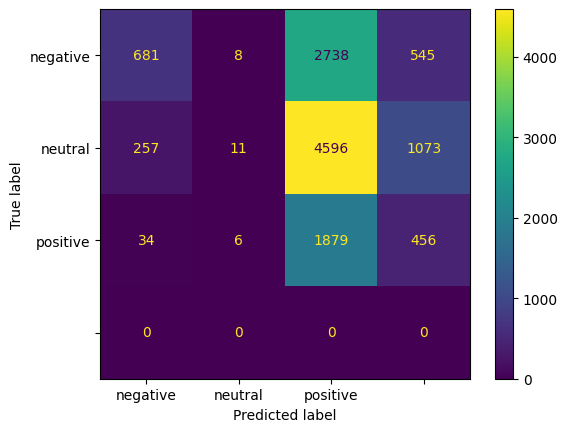

In [ ]:
initial_f1 = eval(model, dataset["test"], tokenizer)
print(f"Initial Macro F1: {initial_f1:.2f}")

# LoRA: [Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685)

В традиционном fine-tuning больших языковых моделей требуется обновление огромного числа параметров, что приводит к высоким вычислительным затратам и потреблению памяти. Метод LoRA решает эту проблему, вводя низкоранговые обновления весов.

Пусть $(W_0 \in \mathbb{R}^{d \times k})$ - исходная матрица весов модели. При адаптации модели предполагается, что обновление весов можно аппроксимировать матрицей низкого ранга:
$$
\Delta W = BA, \quad B \in \mathbb{R}^{d \times r}, \quad A \in \mathbb{R}^{r \times k},
$$
где $r \ll \min(d, k)$.

Обновлённая матрица весов записывается как:
$$
W = W_0 + \Delta W = W_0 + B A.
$$

Основная идея заключается в том, чтобы заморозить исходные параметры $W_0$ и обучать только матрицы $A$ и $B$. Это существенно уменьшает число обучаемых параметров, так как их суммарное количество равно $r \times (d+k)$ по сравнению с $d \times k$ для полной матрицы $W$.

Матрицу $A$ рекомендуется инициализировать нормальным распределением $N(0, \frac{1}{\sqrt{r}})$, а матрицу $B$ нулями. Также не забывайте про скейлинг $\Delta Wx$ на $\frac{\alpha}{r}$, где $\alpha$ гипер-параметр. Во время обучения его можно зафиксировать $\alpha=16$.

## Адаптиация модели с LoRA слоями [4 балла]

В этом задачнии вам потребуется:
1. Дописать класс `LoRALayer` который заменит слои модели
2. Дописать функцию рекурсивного обхода модели, чтобы применить к ней `LinearWithLoRA`
3. Обновить модель

In [ ]:
class LoRALayer(nn.Module):
    """Implements a low-rank adaptation layer."""
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()
        # 5. TODO: Инициализировать матрицы A, B и alpha
        # ==================================
        self.rank = rank
        self.alpha = alpha
        # Матрица B инициализируется нулями
        self.B = nn.Parameter(torch.zeros(in_dim, rank))
        self.A = nn.Parameter(torch.randn(rank, out_dim))

    def forward(self, x):
        lora_update = (x.to(self.B.dtype) @ self.B @ self.A)
        scale = self.alpha / self.rank if self.rank > 0 else self.alpha
        return lora_update * scale
        # ==================================

class LinearWithLoRA(nn.Module):
    """Combines a standard linear layer with a LoRA layer."""
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
             self.linear.bias.requires_grad = False
        self.lora = LoRALayer(linear.in_features, linear.out_features, rank, alpha)
        # ==================================

    def forward(self, x):
        linear_output = self.linear(x)
        lora_output = self.lora(x)
        # Убедимся, что типы совпадают перед сложением
        return linear_output + lora_output.to(linear_output.dtype)


In [ ]:
def apply_peft_to_module(model, adapter_class, r, alpha, target_submodules):
    """Recursively applies a PEFT adapter to target submodules."""
    for name, module in model.named_children():
        module_name = type(module).__name__
        if isinstance(module, nn.Linear) and any(target in name for target in target_submodules):
            new_module = adapter_class(module, r, alpha)
            setattr(model, name, new_module)
        else:
            apply_peft_to_module(module, adapter_class, r, alpha, target_submodules)
# ==================================

### Применим наш LoRA adapter к нашей модели

Обычно для дешевого обучения достаточно применить LoRA к слоям для ключей `k_proj` и значений `v_proj`. Однако, если вы уверены в своих действиях, то не воспрещается обучать и другие слои с помощью LoRA :)

In [ ]:
# Примените peft к модели
apply_peft_to_module(model, LinearWithLoRA, r=8, alpha=16, target_submodules=["k_proj", "v_proj"])

In [ ]:
# Заморозьте не нужные слои


def freeze_layers(model, patterns_to_train):
    """Freezes all layers except those matching patterns."""
    total_params = 0
    trainable_params = 0
    for name, param in model.named_parameters():
        total_params += param.numel()
        param.requires_grad = False
        if any(pattern in name for pattern in patterns_to_train):
            param.requires_grad = True
            trainable_params += param.numel()
            # print(f"Trainable: {name}") # Для отладки
        # else:
            # print(f"Frozen: {name}") # Для отладки

    print(f"Total parameters: {total_params}")
    print(f"Trainable parameters: {trainable_params} ({trainable_params / total_params * 100:.2f}%)")
    return model

## Обучение [2 балла]

*Напутствие:*
Пришло время приступить к обучению модели. После реализации train loop вы заслужите перерыв на 30+ минут – отличный повод с гордостью заявить, что вы заняты обучением модели. Однако длительность отдыха остаётся на ваше усмотрение. Мы рекомендуем ограничиться 2–3 эпохами файнтюна, чтобы избежать излишних вычислительных затрат и переобучения модели.

Обратите внимание, что вам предстоит реализовать классический train loop на PyTorch. Здесь у вас достаточно свободы для выбора гиперпараметров (`batch_size`, `lr`, `num_epochs`). Вы можете использовать дополнительные гиперпараметры на свое усмотрение, например, для оптимизатора.

In [ ]:
def pad_collate_fn(batch: list[dict[str, torch.Tensor]], pad_token_id: int) -> dict[str, torch.Tensor]:
    """Collates and pads a batch of tokenized examples for model input.

    This function takes a batch of examples where each example is a dictionary containing
    token IDs for the prompt, the chosen response, and the rejected response. For each field,
    it extracts the list of token IDs, creates a corresponding attention mask (with ones for each token),
    and then pads the sequences using a `pad` function. The prompt sequences and their attention masks
    are padded on the left, while the chosen and rejected sequences are padded on the right (default).

    Args:
        batch (list[dict[str, torch.Tensor]]): A list of dictionaries with input_ids keys
        pad_token_id (int): Padding value for token IDs.

    Returns:
        dict[str, torch.Tensor]: A dictionary containing the following keys with padded tensors:
            - "prompt_input_ids": Padded token IDs for the prompt (padded on the left).
            - "prompt_attn_mask": Padded attention mask for the prompt (padded on the left, with 1s for actual tokens).
            - "chosen_input_ids": Padded token IDs for the chosen response.
            - "chosen_attn_mask": Padded attention mask for the chosen response.
            - "rejected_input_ids": Padded token IDs for the rejected response.
            - "rejected_attn_mask": Padded attention mask for the rejected response.
    """
    # ========== TODO ==========
    #      Ваш код здесь       =
    # ==========================

    full_input_ids_list = [torch.tensor(item['full_input_ids']) for item in batch]

    prompt_ids_list = [torch.tensor(item['input_ids']) for item in batch]

    input_ids = pad(full_input_ids_list, padding_value=pad_token_id, padding_side="right")

    labels = input_ids.clone()

    attention_mask = (input_ids != pad_token_id).long()

    labels[input_ids == pad_token_id] = -100

    for i, prompt_ids in enumerate(prompt_ids_list):
        prompt_len = len(prompt_ids)
        labels[i, :prompt_len] = -100

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }

In [ ]:
dataloader = DataLoader(
    dataset["train"],
    batch_size=2,
    shuffle=True,
    collate_fn=partial(pad_collate_fn, pad_token_id=tokenizer.pad_token_id),
)
next(iter(dataloader))

{'input_ids': tensor([[    1, 32001,  1587,    13,  2472,  1575,   272, 21790,   302,   272,
           2296,  9394,   299, 28723,   415,  4372,  1023,   347,   865,   624,
           1707, 28747,  5278, 28725,  7087, 28725,   442, 14214, 28723, 32000,
          28705,    13, 32001,  2188,    13, 28738, 12523,  2245, 28747, 14604,
           1838, 24992, 20523,   624,   302,   272,  1722,   369,  2499, 10332,
            286,   993,   506,  4067, 12642,  4187,   262,   356,   559, 19340,
           6207, 28739, 32000, 28705,    13, 32001, 13892,    13, 23238, 32000,
          28705,    13, 32000, 32000, 32000, 32000],
         [    1, 32001,  1587,    13,  2472,  1575,   272, 21790,   302,   272,
           2296,  9394,   299, 28723,   415,  4372,  1023,   347,   865,   624,
           1707, 28747,  5278, 28725,  7087, 28725,   442, 14214, 28723, 32000,
          28705,    13, 32001,  2188,    13, 28738, 12523,  2245, 28747,   345,
          23653,   487,  8181, 28742, 28713,  3187,  3

In [ ]:
def train_model(model, optimizer, train_dataloader, val_dataset, tokenizer, num_epochs, accumulation_steps=1):
    """Trains the model."""
    model.train()
    global_step = 0
    for epoch in range(num_epochs):
        running_loss = 0.0
        optimizer.zero_grad()

        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{num_epochs}")
        for step, batch in enumerate(progress_bar):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            # Forward pass
            outputs = model(**batch)
            loss = outputs.loss

            if accumulation_steps > 1:
                loss = loss / accumulation_steps

            # Backward pass
            loss.backward()

            if (step + 1) % accumulation_steps == 0 or (step + 1) == len(train_dataloader):
                 # Обрезаем градиенты для стабильности
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad() # Очищаем градиенты после шага
                global_step += 1

                # Логирование (можно реже)
                current_loss = loss.item() * accumulation_steps # Возвращаем реальный лосс
                running_loss += current_loss
                if global_step % 50 == 0: # Логируем каждые 50 шагов оптимизатора
                    avg_loss = running_loss / (50 * accumulation_steps if step+1 >= 50*accumulation_steps else (step+1)) # Приблизительно
                    progress_bar.set_postfix({"Avg Loss": f"{avg_loss:.4f}"})
                    # print(f"Epoch {epoch + 1}, Global Step {global_step} | Avg Loss: {avg_loss:.4f}")
                    running_loss = 0.0 # Сбрасываем для следующего интервала

        # Оценка в конце эпохи
        val_f1 = eval(model, val_dataset, tokenizer, show_conf_m=False) # Не показываем матрицу ошибок каждую эпоху
        print(f"Epoch {epoch + 1} | Validation F1: {val_f1:.4f}")
        model.train() # Возвращаем модель в режим обучения

    return model

In [ ]:
BATCH_SIZE = 16
LEARNING_RATE = 3e-4 #
NUM_EPOCHS = 1
GRADIENT_ACCUMULATION_STEPS = 2

train_dataloader_lora = DataLoader(
    dataset["train"],
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=partial(pad_collate_fn, pad_token_id=tokenizer.pad_token_id),
)

# Оптимизируем только размороженные параметры (LoRA)
optimizer_lora = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)


In [ ]:
model.to(DEVICE) # Перемещаем модель снова, т.к. могли создаться новые параметры


MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32768, 896, padding_idx=0)
    (layers): ModuleList(
      (0-19): 20 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear(in_features=896, out_features=896, bias=False)
          (k_proj): LinearWithLoRA(
            (linear): Linear(in_features=896, out_features=448, bias=False)
            (lora): LoRALayer()
          )
          (v_proj): LinearWithLoRA(
            (linear): Linear(in_features=896, out_features=448, bias=False)
            (lora): LoRALayer()
          )
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear(in_features=896, out_features=3584, bias=False)
          (up_proj): Linear(in_features=896, out_features=3584, bias=False)
          (down_proj): Linear(in_features=3584, out_features=896, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): 

In [ ]:
model = train_model(model, optimizer_lora, train_dataloader_lora, dataset["validation"], tokenizer, NUM_EPOCHS, GRADIENT_ACCUMULATION_STEPS)


Epoch 1/1:   0%|          | 0/2851 [00:00<?, ?it/s]

Batching examples:   0%|          | 0/2000 [00:00<?, ? examples/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1 | Validation F1: 0.4710


In [ ]:
for i in range(5):
    input_ids = torch.tensor([dataset["train"][i]["input_ids"]], device=DEVICE)
    generated_text = generate_class(model, tokenizer, input_ids)
    print(dataset["train"][i]["text"])
    print(dataset["train"][i]["str_label"])
    print(generated_text)
    print("=" * 10)

"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
positive
positive 
positive 
positive
positive
positive
"Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
neutral
neutral 
neutral 
neutral 
neutral 

Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.
neutral
neutral 
neutral 
neutral 
neutral 

Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays
neutral
neutral 
neutral 
neutral 
neutral 

@user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"
positive
neutral 
neutral 
neutral 
neutral 



## Оценим результаты

Теперь увидим, как повлиял наш файнтюнинг

  0%|          | 0/123 [00:00<?, ?it/s]

After LoRA Macro F1: 0.44


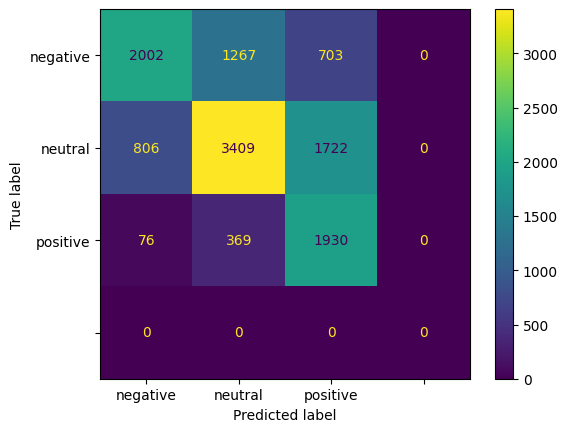

In [ ]:
after_lora_f1 = eval(model, dataset["test"], tokenizer)
print(f"After LoRA Macro F1: {after_lora_f1:.2f}")

In [ ]:
# Загружаем все на хаб

model.push_to_hub(f"{REPO_NAME}-lora", private=True)
tokenizer.push_to_hub(f"{REPO_NAME}-lora", private=True)

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/Aurelianous/llm-course-hw3-lora/commit/db36d0791176aafbc06d4637813b4ee33b720775', commit_message='Upload tokenizer', commit_description='', oid='db36d0791176aafbc06d4637813b4ee33b720775', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Aurelianous/llm-course-hw3-lora', endpoint='https://huggingface.co', repo_type='model', repo_id='Aurelianous/llm-course-hw3-lora'), pr_revision=None, pr_num=None)

In [ ]:
# Очистим память
# del model
#del optimizer_dora

gc.collect()
torch.cuda.empty_cache()

## DoRA: [Weight-Decomposed Low-Rank Adaptation](https://arxiv.org/abs/2402.09353)

В отличие от метода LoRA, где обновление весов модели представлено в виде низкорангового произведения, метод DoRA вводит дополнительную степень гибкости за счёт применения диагональной матрицы для весового масштабирования.

Пусть $W_0 \in \mathbb{R}^{d \times k}$ - исходная матрица весов. В DoRA обновление весов определяется следующим образом:
$$
W = m \frac{W_0 + BA}{\|W_0 + BA \|}
$$

Где $BA$ соответствует использованию LoRA, а $m \in \mathbb{R}^{k}$ обучаемый вектор.

## Обучение модели с помощью DoRA [8 баллов]

В этом задании вам потребуется:
1. Написать с нуля класс `LinearWithDoRA` который использует написанный ранее `LoRALayer` класс
2. Применить его к модели
3. Обучить модель

In [ ]:
class LinearWithDoRA(nn.Module):
    """Combines a standard linear layer with a DoRA layer."""
    def __init__(self, linear, rank, alpha):
        super().__init__()

        self.linear = linear
        self.rank = rank
        self.alpha = alpha

        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
             self.linear.bias.requires_grad = False

        # LoRA часть (как и раньше)
        self.lora = LoRALayer(linear.in_features, linear.out_features, rank, alpha)

        weight_norm = torch.norm(self.linear.weight.float(), p=2, dim=1) # Норма по строкам (out_features)
        self.m = nn.Parameter(weight_norm.clone().detach()) # Обучаемый параметр
        # ==================================

    def forward(self, x):

        W0 = self.linear.weight.float()
        delta_W_T = (self.lora.B @ self.lora.A).T
        lora_scaled_T = self.alpha / self.rank * delta_W_T if self.rank > 0 else self.alpha * delta_W_T

        W_combined = W0 + lora_scaled_T


        norm = torch.norm(W_combined, p=2, dim=1, keepdim=True) + 1e-5 # Размер [out_features, 1]

        W_norm = W_combined / norm

        W_dora = self.m.unsqueeze(1) * W_norm

        output = nn.functional.linear(x, W_dora.to(x.dtype), self.linear.bias)
        return output

Сбрасываем модель и применяем наш DoRA адаптер

In [ ]:
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)

print("Applying DoRA...")
apply_peft_to_module(model, LinearWithDoRA, r=8, alpha=16, target_submodules=["k_proj", "v_proj"])
model.to(DEVICE)

print("Freezing layers for DoRA...")
model = freeze_layers(model, ["lora", ".m"])



Applying DoRA...
Freezing layers for DoRA...
Total parameters: 300049792
Trainable parameters: 193123840 (64.36%)


### Обучение

In [ ]:
BATCH_SIZE_DORA = 16
LEARNING_RATE_DORA = 7e-5
NUM_EPOCHS_DORA = 1
GRADIENT_ACCUMULATION_STEPS_DORA = 2

train_dataset_dora = dataset["train"]

train_dataloader_dora = DataLoader(
    train_dataset_dora,
    batch_size=BATCH_SIZE_DORA,
    shuffle=True,
    collate_fn=partial(pad_collate_fn, pad_token_id=tokenizer.pad_token_id),
)

optimizer_dora = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE_DORA,
    weight_decay=0.01
)

In [ ]:
model = train_model(model, optimizer_dora, train_dataloader_dora, dataset["validation"], tokenizer, NUM_EPOCHS_DORA, GRADIENT_ACCUMULATION_STEPS_DORA)


Epoch 1/1:   0%|          | 0/2851 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1 | Validation F1: 0.5399


In [ ]:
for i in range(5):
    input_ids = torch.tensor([dataset["train"][i]["input_ids"]], device=DEVICE)
    generated_text = generate_class(model, tokenizer, input_ids)
    print(dataset["train"][i]["text"])
    print(dataset["train"][i]["str_label"])
    print(generated_text)
    print("=" * 10)

"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
positive
positivepospospospospospospospospospospospospospos
"Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
neutral
neutralneutralneutralneutralneutralneutralneutralneutral
Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.
neutral
neutralneutralneutralneutralneutralneutralneutralneutral
Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays
neutral
neutralneutralneutralneutralneutralneutralneutralneutral
@user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"
positive
neutralneutralneutralneutralneutralneutralneutralneutral


  0%|          | 0/123 [00:00<?, ?it/s]

After DoRA Macro F1: 0.52


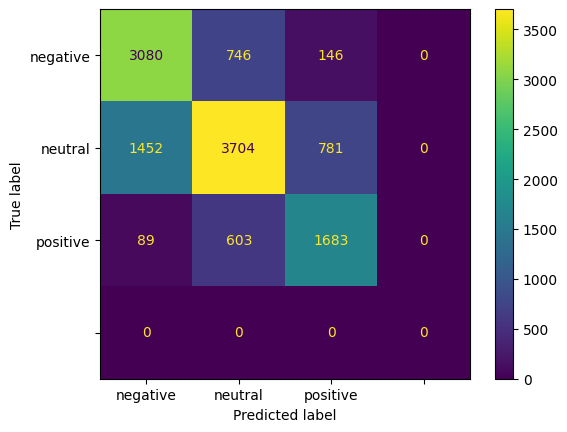

In [ ]:
after_dora_f1 = eval(model, dataset["test"], tokenizer)
print(f"After DoRA Macro F1: {after_dora_f1:.2f}")

  0%|          | 0/123 [00:00<?, ?it/s]

After DoRA Macro F1: 0.52


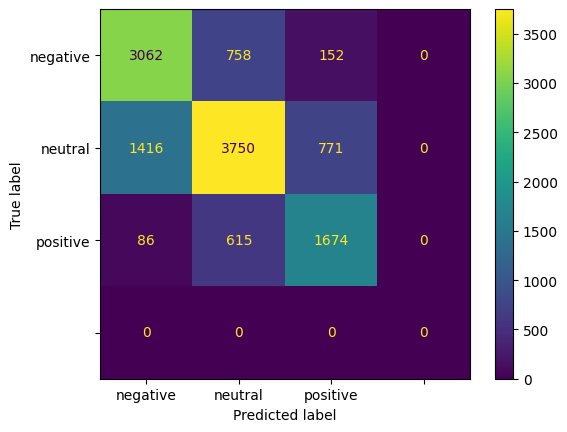

In [ ]:
after_dora_f1 = eval(model, dataset["test"], tokenizer)
print(f"After DoRA Macro F1: {after_dora_f1:.2f}")

Для качественного обучения доры в этой задаче нужно постараться.
Будем считать, что если качество > 0.5, то задание с учетом правильности кода решено верно

In [ ]:
# Загружаем все на хаб

model.push_to_hub(f"{REPO_NAME}-dora", private=True)
tokenizer.push_to_hub(f"{REPO_NAME}-dora", private=True)

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/Aurelianous/llm-course-hw3-dora/commit/ebe486c12870cc5b0a26026412e982b8450a63b7', commit_message='Upload tokenizer', commit_description='', oid='ebe486c12870cc5b0a26026412e982b8450a63b7', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Aurelianous/llm-course-hw3-dora', endpoint='https://huggingface.co', repo_type='model', repo_id='Aurelianous/llm-course-hw3-dora'), pr_revision=None, pr_num=None)

In [ ]:
# Очистим память
gc.collect()
torch.cuda.empty_cache()

## Frameworks way [4 балла]

### QLoRA: [Efficient Finetuning of Quantized LLMs](https://arxiv.org/pdf/2305.14314)

Метод QLoRA направлен на эффективное дообучение предварительно обученных больших языковых моделей с использованием квантования весов. Основная идея заключается в том, что во время обратного распространения ошибки модель квантует исходные веса с точностью до 4 бит, что позволяет значительно сократить использование GPU памяти. Для обработки пиков памяти при этом применяются страничные оптимизаторы.

В результате, применение QLoRA часто приводит к экономии GPU памяти примерно на $\dfrac{1}{3}$, однако время обучения при этом может увеличиться почти на $\dfrac{1}{4}$ по сравнению с традиционными методами дообучения.

Такой компромисс между экономией памяти и увеличением времени обучения делает QLoRA привлекательным решением в сценариях, где ресурсы ограничены, а эффективность использования памяти критически важна.

Теперь с таким прекрасным инструментом как QLoRA можем рассмотреть более тяжелую модель аж 1.1B :)

Используйте документацию библиотек [HuggingFace Transformers](https://huggingface.co/docs/transformers/index) и [PEFT](https://huggingface.co/docs/peft/index).

1. Конфигурация квантизации (`BitsAndBytesConfig`): Подберите тип 4-битной квантизации (`bnb_4bit_quant_type`) и размерность подсчёта (`bnb_4bit_compute_dtype`)

2. Настройка LoRA-адаптеров (`LoraConfig`):
    - Подберите и обоснуйте значения следующих гиперпараметров:
        - `lora_alpha`
        - `lora_dropout`
        - `r`
    - Выберите модули модели, к которым следует применять LoRA-адаптеры (`target_modules`).

3. Настройка параметров обучения (`TrainingArguments`, `SFTTrainer`):
Используя документацию и подберите параметры:
    - `learning_rate`
    - `num_train_epochs`
    - `gradient_accumulation_steps`
    - `lr_scheduler_type`
    - `per_device_train_batch_size`
    - другие параметры по необходимости

4. Проведение обучения и анализ результатов:
    - Запустите обучение модели.
    - Оцените модель до и после обучения.
    - сохраните модель


In [ ]:
print("--- A. QLoRA 设置 ---")
LARGE_MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
# 建议为这次运行使用新的仓库名称，以免覆盖之前的实验
SYSTEM_PROMPT = "Classify the sentiment of the following tweet. The answer should be only one word: positive, negative, or neutral."


--- A. QLoRA 设置 ---


In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
model = AutoModelForCausalLM.from_pretrained(
    LARGE_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(LARGE_MODEL_NAME)


tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

In [ ]:
if tokenizer.pad_token is None:
    if "<PAD>" in tokenizer.get_vocab():
        tokenizer.pad_token = "<PAD>"
        print("Set tokenizer pad_token to <PAD>.")
    else:
        print("Adding new PAD token to tokenizer.")
        tokenizer.add_special_tokens({'pad_token': '<PAD>'})
        print("Resizing token embeddings...")
        # 注意: 调整大小应在加载模型后、应用 PEFT 前完成
        model.resize_token_embeddings(len(tokenizer))
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.convert_tokens_to_ids(tokenizer.pad_token)
tokenizer.padding_side = "left"


In [ ]:
def process_example(example, *, tokenizer, system_prompt=SYSTEM_PROMPT):
    user_message = f"Tweet text: \"{example['text']}\""
    chat_for_inference = [{"role": "system", "content": system_prompt}, {"role": "user", "content": user_message}]
    try:
        prompt_str = tokenizer.apply_chat_template(chat_for_inference, add_generation_prompt=True, tokenize=False)
    except Exception as e:
        logging.error(f"应用聊天模板生成推理提示时出错: {e}")
        prompt_str = f"<|system|>\n{system_prompt}<|user|>\n{user_message}<|assistant|>\n"

    eos_token_str = tokenizer.eos_token
    assistant_marker = "<|assistant|>"
    if eos_token_str and assistant_marker in prompt_str:
        parts = prompt_str.split(assistant_marker)
        if len(parts) == 2:
            part_before_assistant = parts[0]
            part_after_assistant = parts[1]
            cleaned_part_before = part_before_assistant.replace(eos_token_str, "").strip()
            prompt_str = cleaned_part_before + " " + assistant_marker + part_after_assistant
            prompt_str = prompt_str.replace(" \n", "\n").strip()

    chat_full = [{"role": "system", "content": system_prompt}, {"role": "user", "content": user_message}, {"role": "assistant", "content": example["str_label"]}]
    try:
        full_prompt_str = tokenizer.apply_chat_template(chat_full, tokenize=False)
    except Exception as e:
         logging.error(f"应用聊天模板生成完整提示时出错: {e}")
         full_prompt_str = ""

    example['prompt'] = prompt_str
    example['full_prompt'] = full_prompt_str
    return example

In [ ]:
def tokenize_prompt(examples, tokenizer, max_length=256):
    return tokenizer(examples["prompt"], truncation=True, max_length=max_length, padding=False)

# 3. convert_instruction_format (提取自 [source: 222, 264, 393, 399])
def convert_instruction_format(example, system_prompt=SYSTEM_PROMPT):
    conversation = [{"role": "system", "content": system_prompt}, {"role": "user", "content": f"Tweet text: \"{example['text']}\""}, {"role": "assistant", "content": example["str_label"]}]
    return {"messages": conversation}

# 4. postprocess_sentiment_tinyllama (提取自 [source: 222, 223, 268, 269, 403, 404])
def postprocess_sentiment_tinyllama(output_text: str) -> str:
    parts = re.split(r'<\|assistant\|>', output_text, flags=re.IGNORECASE)
    text_to_process = parts[-1].strip() if len(parts) > 1 else output_text
    text_lower = text_to_process.lower()
    if 'positive' in text_lower and "not positive" not in text_lower and "non-positive" not in text_lower: return "positive"
    if 'negative' in text_lower and "not negative" not in text_lower and "non-negative" not in text_lower: return "negative"
    if 'neutral' in text_lower and "not neutral" not in text_lower: return "neutral"
    return ""

In [ ]:
@torch.inference_mode
def eval(model, eval_data, tokenizer, show_conf_m=True, batch_size=32):
    print("\n--- 进入 eval 函数内部 ---")
    try:
        print(f"接收到的 Tokenizer: {tokenizer.name_or_path}, Pad ID: {tokenizer.pad_token_id}")
        first_eval_sample_ids = eval_data[0]["input_ids"]
        decoded_internal_check = tokenizer.decode(first_eval_sample_ids, skip_special_tokens=False)
        print("在 eval 内部解码 eval_data[0]['input_ids'] 结果:")
        print(decoded_internal_check)
    except Exception as e:
        print(f"在 eval 内部解码第一个样本时出错: {e}")
    print("-" * 50)

    model.eval()
    name2idx = {v: k for k, v in IDX2NAME.items()}
    name2idx[""] = len(name2idx)
    ground_truth = []
    predicted = []
    total_processed_examples = 0
    postprocess_func = postprocess_sentiment_tinyllama

    print(f"开始评估循环，批次大小: {batch_size}...")
    try:
        data_iterator = eval_data.batch(batch_size)
    except AttributeError:
         print("警告: eval_data 不支持 .batch() 方法。")
         data_iterator = eval_data

    for batch_idx, examples in enumerate(tqdm(data_iterator, desc="评估中")):
        try:
            input_ids_list = [torch.tensor(item) for item in examples["input_ids"]]
            if not input_ids_list: continue
            input_ids = pad(input_ids_list, padding_value=tokenizer.pad_token_id, padding_side="left").to(DEVICE)
            attention_mask_list = [torch.ones(len(item), dtype=torch.long) for item in input_ids_list]
            attention_mask = pad(attention_mask_list, padding_value=0, padding_side="left").to(DEVICE)
        except Exception as e:
            print(f"\n准备批次 {batch_idx} 时出错: {e}")
            continue

        if batch_idx == 0 and len(input_ids) > 0:
             print(f"\n--- 调试循环中的输入 (批次 0, 样本 0) ---")
             decoded_input_loop = tokenizer.decode(input_ids[0], skip_special_tokens=False)
             print(f"从批次中解码的 input_ids[0]:\n{decoded_input_loop}")
             print("-" * 50)

        try:
            # 使用 beam search 可能对于短文本生成更稳定一点，但 greedy 通常也可以
            output_ids = model.generate(input_ids, attention_mask=attention_mask,
                                        max_new_tokens=20,
                                        pad_token_id=tokenizer.pad_token_id,
                                        do_sample=False, # 对于分类任务，通常不需要采样
                                        num_beams=1) # 使用 greedy decoding (num_beams=1)
            input_len = input_ids.shape[1]
            shrinked_ids_list = []
            for out_id in output_ids:
                 if len(out_id) > input_len: shrinked_ids_list.append(out_id[input_len:])
                 else: shrinked_ids_list.append(torch.tensor([], dtype=torch.long, device=DEVICE))
            texts = tokenizer.batch_decode(shrinked_ids_list, skip_special_tokens=True, clean_up_tokenization_spaces=True)
        except Exception as e:
            print(f"\n模型生成批次 {batch_idx} 时出错: {e}")
            continue

        if len(texts) != len(examples["str_label"]):
             print(f"\n警告: 批次 {batch_idx} 中生成文本数与标签数不匹配。跳过此批次。")
             continue

        for i in range(len(examples["str_label"])):
            raw_output_text = texts[i]
            predicted_sentiment = postprocess_func(raw_output_text)
            if total_processed_examples < 5:
                print(f"\n--- 样本 {total_processed_examples} (批次 {batch_idx}, 索引 {i}) ---")
                print(f"原始输出: '{raw_output_text}'")
                print(f"真实标签: '{examples['str_label'][i]}'")
                print(f"处理后预测: '{predicted_sentiment}'")
                print("-" * 30)
            ground_truth.append(name2idx[examples["str_label"][i]])
            predicted.append(name2idx.get(predicted_sentiment, name2idx[""]))
            total_processed_examples += 1

    if not ground_truth or not predicted:
         print("\n评估失败: 未收集到有效的真实标签或预测标签。")
         model.train()
         return 0.0

    print(f"\n总共处理样本数: {total_processed_examples}")
    if show_conf_m:
        try:
            print("\n生成混淆矩阵...")
            labels_present = sorted(list(set(ground_truth) | set(predicted)))
            display_labels_actual = [k for k, v in name2idx.items() if v in labels_present]
            conf_m = confusion_matrix(ground_truth, predicted, labels=labels_present)
            disp = ConfusionMatrixDisplay(conf_m, display_labels=display_labels_actual)
            disp.plot(cmap=plt.cm.viridis); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
            print("混淆矩阵已生成。")
        except Exception as e:
            print(f"\n显示混淆矩阵时出错: {e}")

    # 修正：只计算和打印一次 F1
    f1 = f1_score(ground_truth, predicted, labels=list(name2idx.values())[:-1], average="macro", zero_division=0.0)
    print(f"\n计算得到的 Macro F1 (排除空预测): {f1:.4f}")
    model.train()
    return f1

In [ ]:
# 6. pad 函数 (来自原 notebook)
def pad(tensors: list[torch.Tensor], padding_value: int = 0, padding_side: str = "left") -> torch.Tensor:
    """Pads a list of tensors to the same size along their leading dimension."""
    if not tensors: return torch.empty((0,))
    if not isinstance(tensors[0], torch.Tensor): raise TypeError(f"Expected a list of torch.Tensor, but received type: {type(tensors[0])}")
    max_len = max(t.size(0) for t in tensors)
    device = tensors[0].device; dtype = tensors[0].dtype
    batch_size = len(tensors)
    padded_tensors = torch.full((batch_size, max_len), padding_value, dtype=dtype, device=device)
    for i, t in enumerate(tensors):
        len_t = t.size(0)
        if padding_side == "right": padded_tensors[i, :len_t] = t
        elif padding_side == "left": padded_tensors[i, max_len - len_t:] = t
        else: raise ValueError("padding_side must be 'left' or 'right'")
    return padded_tensors

In [ ]:
print("\n--- D. 执行数据处理流程 ---")
# 加载原始数据集 (如果尚未加载)
print("加载原始数据集...")
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")
# 添加 str_label 列
def add_str_label(example):
    example["str_label"] = IDX2NAME.get(example["label"], "unknown") # 使用 get 更安全
    return example
dataset = dataset.map(add_str_label, num_proc=4)
print("原始数据集准备完成。")


--- D. 执行数据处理流程 ---
加载原始数据集...


Map (num_proc=4):   0%|          | 0/45615 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/12284 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/2000 [00:00<?, ? examples/s]

原始数据集准备完成。


In [ ]:
from datasets import DatasetDict

In [ ]:
processed_datasets_dict = DatasetDict()
final_eval_datasets_dict = DatasetDict()
sft_datasets_dict = DatasetDict()

In [ ]:
print("\n=== 步骤 D.1: 应用 process_example ===")
for split in dataset.keys():
    processed_datasets_dict[split] = dataset[split].map(
        process_example, fn_kwargs={"tokenizer": tokenizer, "system_prompt": SYSTEM_PROMPT},
        num_proc=4, load_from_cache_file=False, desc=f"D.1 处理 {split}"
    )
    if 'prompt' not in processed_datasets_dict[split].column_names: raise ValueError(f"'prompt' 列未能在 {split} 创建")
    print(f"'{split}' prompt 创建完成。")

print("\n=== 步骤 D.2: 使用 prompt 分词 ===")
for split in processed_datasets_dict.keys():
    processed_datasets_dict[split] = processed_datasets_dict[split].map(
        partial(tokenize_prompt, tokenizer=tokenizer, max_length=256),
        batched=True, num_proc=4, load_from_cache_file=False, desc=f"D.2 分词 {split}"
    )
    if 'input_ids' not in processed_datasets_dict[split].column_names: raise ValueError(f"'input_ids' 列未能在 {split} 创建")
    print(f"'{split}' 分词完成。")

print("\n=== 步骤 D.3: 清理列，准备评估数据集 ===")
columns_to_keep_for_eval = ["input_ids", "attention_mask", "label", "str_label"]
for split in processed_datasets_dict.keys():
    if not all(col in processed_datasets_dict[split].column_names for col in columns_to_keep_for_eval):
        raise ValueError(f"'{split}' 数据集在分词后缺少评估所需列。可用: {processed_datasets_dict[split].column_names}")
    final_eval_datasets_dict[split] = processed_datasets_dict[split].select_columns(columns_to_keep_for_eval)
    print(f"'{split}' 评估数据集准备完成。列: {final_eval_datasets_dict[split].column_names}")

print("\n=== 步骤 D.4: 准备 SFTTrainer 数据集 ===")
columns_needed_for_sft = ["text", "str_label"]
for split in processed_datasets_dict.keys():
    if not all(col in processed_datasets_dict[split].column_names for col in columns_needed_for_sft):
        # 如果 'text' 不在，可能需要从原始 'dataset' 获取
        if 'text' not in processed_datasets_dict[split].column_names:
            print(f"警告: processed_dataset['{split}'] 中缺少 'text' 列，尝试从原始 dataset 获取。")
            # 这一步比较复杂，需要确保索引对齐，更简单的做法是在 D.2 分词时不移除 text 列
            # 或者在 D.1 之后直接创建 SFT 数据集
            # 为简化，这里假设 D.2 没有移除 text
            pass # 假设 text 列仍然存在于 processed_datasets_dict[split]
        # raise ValueError(f"'{split}' 数据集缺少创建 SFT 格式所需的列 ('text', 'str_label')。可用: {processed_datasets_dict[split].column_names}")
    temp_data = processed_datasets_dict[split].select_columns(columns_needed_for_sft)
    sft_datasets_dict[split] = temp_data.map(
        convert_instruction_format, fn_kwargs={"system_prompt": SYSTEM_PROMPT},
        remove_columns=columns_needed_for_sft, load_from_cache_file=False, desc=f"D.4 转换 SFT {split}"
    )
    print(f"'{split}' SFTTrainer 数据集准备完成。")


=== 步骤 D.1: 应用 process_example ===


D.1 处理 train (num_proc=4):   0%|          | 0/45615 [00:00<?, ? examples/s]

'train' prompt 创建完成。


D.1 处理 test (num_proc=4):   0%|          | 0/12284 [00:00<?, ? examples/s]

'test' prompt 创建完成。


...

'train' SFTTrainer 数据集准备完成。


D.4 转换 SFT test:   0%|          | 0/12284 [00:00<?, ? examples/s]

'test' SFTTrainer 数据集准备完成。


D.4 转换 SFT validation:   0%|          | 0/2000 [00:00<?, ? examples/s]

'validation' SFTTrainer 数据集准备完成。


In [ ]:
# --- D.5 最终数据验证 ---
print("\n--- D.5 最终数据验证 ---")
try:
    test_data_for_eval = final_eval_datasets_dict["test"]
    sft_train_data = sft_datasets_dict["train"]
    print("\n验证最终用于评估的测试集样本 0 的 input_ids:")
    decoded_check = tokenizer.decode(test_data_for_eval[0]["input_ids"], skip_special_tokens=False)
    print(decoded_check)
    # ... (验证逻辑同前) ...
    if "<|im_start|>" in decoded_check: print("警告：包含旧标记！")
    elif "<|system|>" in decoded_check: print("评估数据格式初步检查通过。")
    else: print("评估数据格式检查通过（无旧标记）。")

    print("\n验证最终用于训练的SFT训练集样本 0:")
    print(sft_train_data[0])
except Exception as e:
    print(f"最终数据验证时出错: {e}")


--- D.5 最终数据验证 ---

验证最终用于评估的测试集样本 0 的 input_ids:
<s> <|system|>
Classify the sentiment of the following tweet. The answer should be only one word: positive, negative, or neutral.
<|user|>
Tweet text: "@user @user what do these '1/2 naked pics' have to do with anything? They're not even like that." <|assistant|>
评估数据格式初步检查通过。

验证最终用于训练的SFT训练集样本 0:
{'messages': [{'content': 'Classify the sentiment of the following tweet. The answer should be only one word: positive, negative, or neutral.', 'role': 'system'}, {'content': 'Tweet text: ""QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin""', 'role': 'user'}, {'content': 'positive', 'role': 'assistant'}]}


In [ ]:
peft_config = LoraConfig(
    lora_alpha=32, r=16, lora_dropout=0.1, bias="none", task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]
)
model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, peft_config)
print("\n模型已应用 PEFT 配置:")
model.print_trainable_parameters()



模型已应用 PEFT 配置:
trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079


In [ ]:
training_arguments = TrainingArguments(
    output_dir="./results-tinyllama-qlora-structured", # 使用新目录
    num_train_epochs=1,
    per_device_train_batch_size=16, # 确认合适的批次大小
    gradient_accumulation_steps=2,
    optim="paged_adamw_8bit",
    save_strategy="steps", save_steps=200,
    logging_steps=25, learning_rate=2e-5, weight_decay=0.01,
    bf16=True, max_grad_norm=0.3, warmup_ratio=0.03,
    group_by_length=True, lr_scheduler_type="cosine",
    report_to="tensorboard",
    eval_strategy="steps", eval_steps=200,
    load_best_model_at_end=True, metric_for_best_model="eval_loss", greater_is_better=False,
)

In [ ]:
sft_eval_dataset_for_trainer = sft_datasets_dict.get("validation")
if sft_eval_dataset_for_trainer is None: print("警告：找不到 SFT Trainer 的验证集。")


In [ ]:
trainer = SFTTrainer(
    model=model,
    train_dataset=sft_datasets_dict["train"],
    eval_dataset=sft_eval_dataset_for_trainer,
    peft_config=peft_config,
    processing_class=tokenizer, # 显式传递 tokenizer
    args=training_arguments,
    #max_seq_length=256 # 设置最大序列长度
)

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [ ]:
print("\n--- 检查 SFT 训练数据格式 (第一个样本) ---")
try:
    # 确保 sft_datasets_dict 变量包含处理后的数据
    if "train" in sft_datasets_dict and len(sft_datasets_dict["train"]) > 0:
         print(sft_datasets_dict["train"][0]) # 打印第一个样本的内容
    else:
         print("错误：无法访问 sft_datasets_dict['train'][0]")
except Exception as e:
    print(f"检查 SFT 训练数据时出错: {e}")


--- 检查 SFT 训练数据格式 (第一个样本) ---
{'messages': [{'content': 'Classify the sentiment of the following tweet. The answer should be only one word: positive, negative, or neutral.', 'role': 'system'}, {'content': 'Tweet text: ""QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin""', 'role': 'user'}, {'content': 'positive', 'role': 'assistant'}]}


In [ ]:
# adding MLP
print("\n--- E. PEFT 和训练设置 (尝试加入 MLP 层) ---")

print(f"重新加载基础模型 {LARGE_MODEL_NAME} 和分词器...")
model = AutoModelForCausalLM.from_pretrained(
    LARGE_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(LARGE_MODEL_NAME)
if tokenizer.pad_token is None:
    if "<PAD>" in tokenizer.get_vocab(): tokenizer.pad_token = "<PAD>"
    else: tokenizer.add_special_tokens({'pad_token': '<PAD>'})
if tokenizer.pad_token_id is None: tokenizer.pad_token_id = tokenizer.convert_tokens_to_ids(tokenizer.pad_token)
tokenizer.padding_side = "left"

print("loaded")


peft_config = LoraConfig(
    lora_alpha=32,
    lora_dropout=0.1,
    r=16,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
)
print("新的 PEFT 配置 (含 MLP):", peft_config.target_modules)

model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, peft_config)
print("\n模型已应用新的 PEFT 配置:")
model.print_trainable_parameters()

training_arguments = TrainingArguments(
    output_dir="./results-tinyllama-qlora-mlp",
    num_train_epochs=1,
    per_device_train_batch_size=16, # 根据显存调整
    gradient_accumulation_steps=2,  # 有效批次 32
    optim="paged_adamw_8bit",
    save_strategy="steps", save_steps=200,
    logging_steps=25,
    learning_rate=1e-4,
    weight_decay=0.01, bf16=True, max_grad_norm=0.3, warmup_ratio=0.03,
    group_by_length=True, lr_scheduler_type="cosine", report_to="tensorboard",
    eval_strategy="steps", eval_steps=200,
    load_best_model_at_end=True, metric_for_best_model="eval_loss", greater_is_better=False,
)


sft_eval_dataset_for_trainer = sft_datasets_dict.get("validation")
if sft_eval_dataset_for_trainer is None: print("警告：找不到 SFT Trainer 的验证集。")

trainer = SFTTrainer(
    model=model,
    train_dataset=sft_datasets_dict["train"],
    eval_dataset=sft_eval_dataset_for_trainer,
    peft_config=peft_config,
    processing_class=tokenizer,
    args=training_arguments,
    #max_seq_length=256 # 设置序列长度
)
print("SFTTrainer 初始化完成 (使用含 MLP 的 PEFT 配置)。")


print("\n--- F. 开始使用新配置重新训练 ---")

print("训练完成。")


--- E. PEFT 和训练设置 (尝试加入 MLP 层) ---
重新加载基础模型 TinyLlama/TinyLlama-1.1B-Chat-v1.0 和分词器...
loaded
新的 PEFT 配置 (含 MLP): {'v_proj', 'o_proj', 'down_proj', 'q_proj', 'gate_proj', 'k_proj', 'up_proj'}


No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.



模型已应用新的 PEFT 配置:
trainable params: 12,615,680 || all params: 1,112,664,064 || trainable%: 1.1338
SFTTrainer 初始化完成 (使用含 MLP 的 PEFT 配置)。

--- F. 开始使用新配置重新训练 ---
训练完成。



The best performance achieved here was f1:0.21, I dont know how I can make it better so far, there are lots of empty output now, and I am sure I did some bad moves to make it got worse , it should be much better....
=================
Hope the 300 computation units worth it...

In [ ]:
trainer.train()

/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
200,0.952200,1.127524
400,0.921000,1.095775
600,0.937700,1.076549
800,0.927900,1.069445
1000,0.895800,1.064078
1200,0.907100,1.061054
1400,0.903600,1.060414


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/

TrainOutput(global_step=1425, training_loss=1.086059206243147, metrics={'train_runtime': 1399.1404, 'train_samples_per_second': 32.602, 'train_steps_per_second': 1.018, 'total_flos': 2.712829021205299e+16, 'train_loss': 1.086059206243147})

In [ ]:
final_f1_score = eval(trainer.model, final_eval_datasets_dict["test"], tokenizer, show_conf_m=True)



--- 进入 eval 函数内部 ---
接收到的 Tokenizer: TinyLlama/TinyLlama-1.1B-Chat-v1.0, Pad ID: 2
在 eval 内部解码 eval_data[0]['input_ids'] 结果:
<s> <|system|>
Classify the sentiment of the following tweet. The answer should be only one word: positive, negative, or neutral.
<|user|>
Tweet text: "@user @user what do these '1/2 naked pics' have to do with anything? They're not even like that." <|assistant|>
--------------------------------------------------
开始评估循环，批次大小: 32...


评估中:   0%|          | 0/384 [00:00<?, ?it/s]


--- 调试循环中的输入 (批次 0, 样本 0) ---
从批次中解码的 input_ids[0]:
</s></s></s></s></s></s></s></s></s></s></s></s></s></s><s> <|system|>
Classify the sentiment of the following tweet. The answer should be only one word: positive, negative, or neutral.
<|user|>
Tweet text: "@user @user what do these '1/2 naked pics' have to do with anything? They're not even like that." <|assistant|>
--------------------------------------------------

--- 样本 0 (批次 0, 索引 0) ---
原始输出: ''
真实标签: 'neutral'
处理后预测: ''
------------------------------

--- 样本 1 (批次 0, 索引 1) ---
原始输出: ''
真实标签: 'neutral'
处理后预测: ''
------------------------------

--- 样本 2 (批次 0, 索引 2) ---
原始输出: ''
真实标签: 'neutral'
处理后预测: ''
------------------------------

--- 样本 3 (批次 0, 索引 3) ---
原始输出: ''
真实标签: 'positive'
处理后预测: ''
------------------------------

--- 样本 4 (批次 0, 索引 4) ---
原始输出: ''
真实标签: 'negative'
处理后预测: ''
------------------------------

总共处理样本数: 12284

生成混淆矩阵...

显示混淆矩阵时出错: name 'plt' is not defined

计算得到的 Macro F1 (排除空预测): 0.0152


In [ ]:

import logging

from datasets import load_dataset, DatasetDict

import matplotlib.pyplot as plt

# --- A. 设置 ---
print("--- A. QLoRA 设置 ---")
LARGE_MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
# 建议为这次运行使用新的仓库名称，以免覆盖之前的实验
NEW_QLORA_REPO_NAME = f"{REPO_NAME}-tinyllama-qlora-structured"
SYSTEM_PROMPT = "Classify the sentiment of the following tweet. The answer should be only one word: positive, negative, or neutral."

# 假设这些变量已在前面定义
# IDX2NAME = {0: "negative", 1: "neutral", 2: "positive"}
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# REPO_NAME = f"{username}/llm-course-hw3" # 假设 username 已定义
# set_seed(SEED) # 假设 SEED 已定义并调用了 set_seed

# --- B. 加载模型和分词器 ---
print(f"\n--- B. 加载模型 {LARGE_MODEL_NAME} 和分词器 ---")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
model = AutoModelForCausalLM.from_pretrained(
    LARGE_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(LARGE_MODEL_NAME)

# 处理 Pad Token (从 `副本(3).txt` 中提取的逻辑 [source: 218, 365])
if tokenizer.pad_token is None:
    if "<PAD>" in tokenizer.get_vocab():
        tokenizer.pad_token = "<PAD>"
        print("Set tokenizer pad_token to <PAD>.")
    else:
        print("Adding new PAD token to tokenizer.")
        tokenizer.add_special_tokens({'pad_token': '<PAD>'})
        print("Resizing token embeddings...")
        # 注意: 调整大小应在加载模型后、应用 PEFT 前完成
        model.resize_token_embeddings(len(tokenizer))
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.convert_tokens_to_ids(tokenizer.pad_token)
tokenizer.padding_side = "left"

print(f"Tokenizer: {tokenizer.name_or_path}, Pad ID: {tokenizer.pad_token_id}")

# --- C. 定义处理函数 ---
print("\n--- C. 定义处理函数 ---")

# 1. process_example (提取自 [source: 219-221, 382-387])
def process_example(example, *, tokenizer, system_prompt=SYSTEM_PROMPT):
    user_message = f"Tweet text: \"{example['text']}\""
    chat_for_inference = [{"role": "system", "content": system_prompt}, {"role": "user", "content": user_message}]
    try:
        prompt_str = tokenizer.apply_chat_template(chat_for_inference, add_generation_prompt=True, tokenize=False)
    except Exception as e:
        logging.error(f"应用聊天模板生成推理提示时出错: {e}")
        prompt_str = f"<|system|>\n{system_prompt}<|user|>\n{user_message}<|assistant|>\n"

    eos_token_str = tokenizer.eos_token
    assistant_marker = "<|assistant|>"
    if eos_token_str and assistant_marker in prompt_str:
        parts = prompt_str.split(assistant_marker)
        if len(parts) == 2:
            part_before_assistant = parts[0]
            part_after_assistant = parts[1]
            cleaned_part_before = part_before_assistant.replace(eos_token_str, "").strip()
            prompt_str = cleaned_part_before + " " + assistant_marker + part_after_assistant
            prompt_str = prompt_str.replace(" \n", "\n").strip()

    chat_full = [{"role": "system", "content": system_prompt}, {"role": "user", "content": user_message}, {"role": "assistant", "content": example["str_label"]}]
    try:
        full_prompt_str = tokenizer.apply_chat_template(chat_full, tokenize=False)
    except Exception as e:
         logging.error(f"应用聊天模板生成完整提示时出错: {e}")
         full_prompt_str = ""

    example['prompt'] = prompt_str
    example['full_prompt'] = full_prompt_str
    return example

# 2. tokenize_prompt (提取自 [source: 221, 390])
def tokenize_prompt(examples, tokenizer, max_length=256):
    return tokenizer(examples["prompt"], truncation=True, max_length=max_length, padding=False)

# 3. convert_instruction_format (提取自 [source: 222, 264, 393, 399])
def convert_instruction_format(example, system_prompt=SYSTEM_PROMPT):
    conversation = [{"role": "system", "content": system_prompt}, {"role": "user", "content": f"Tweet text: \"{example['text']}\""}, {"role": "assistant", "content": example["str_label"]}]
    return {"messages": conversation}

# 4. postprocess_sentiment_tinyllama (提取自 [source: 222, 223, 268, 269, 403, 404])
def postprocess_sentiment_tinyllama(output_text: str) -> str:
    parts = re.split(r'<\|assistant\|>', output_text, flags=re.IGNORECASE)
    text_to_process = parts[-1].strip() if len(parts) > 1 else output_text
    text_lower = text_to_process.lower()
    if 'positive' in text_lower and "not positive" not in text_lower and "non-positive" not in text_lower: return "positive"
    if 'negative' in text_lower and "not negative" not in text_lower and "non-negative" not in text_lower: return "negative"
    if 'neutral' in text_lower and "not neutral" not in text_lower: return "neutral"
    return ""

# 5. eval (提取自 [source: 405-416], 并修正了内部重复代码)
@torch.inference_mode
def eval(model, eval_data, tokenizer, show_conf_m=True, batch_size=32):
    print("\n--- 进入 eval 函数内部 ---")
    try:
        print(f"接收到的 Tokenizer: {tokenizer.name_or_path}, Pad ID: {tokenizer.pad_token_id}")
        first_eval_sample_ids = eval_data[0]["input_ids"]
        decoded_internal_check = tokenizer.decode(first_eval_sample_ids, skip_special_tokens=False)
        print("在 eval 内部解码 eval_data[0]['input_ids'] 结果:")
        print(decoded_internal_check)
    except Exception as e:
        print(f"在 eval 内部解码第一个样本时出错: {e}")
    print("-" * 50)

    model.eval()
    name2idx = {v: k for k, v in IDX2NAME.items()}
    name2idx[""] = len(name2idx)
    ground_truth = []
    predicted = []
    total_processed_examples = 0
    postprocess_func = postprocess_sentiment_tinyllama

    print(f"开始评估循环，批次大小: {batch_size}...")
    try:
        data_iterator = eval_data.batch(batch_size)
    except AttributeError:
         print("警告: eval_data 不支持 .batch() 方法。")
         data_iterator = eval_data

    for batch_idx, examples in enumerate(tqdm(data_iterator, desc="评估中")):
        try:
            input_ids_list = [torch.tensor(item) for item in examples["input_ids"]]
            if not input_ids_list: continue
            input_ids = pad(input_ids_list, padding_value=tokenizer.pad_token_id, padding_side="left").to(DEVICE)
            attention_mask_list = [torch.ones(len(item), dtype=torch.long) for item in input_ids_list]
            attention_mask = pad(attention_mask_list, padding_value=0, padding_side="left").to(DEVICE)
        except Exception as e:
            print(f"\n准备批次 {batch_idx} 时出错: {e}")
            continue

        if batch_idx == 0 and len(input_ids) > 0:
             print(f"\n--- 调试循环中的输入 (批次 0, 样本 0) ---")
             decoded_input_loop = tokenizer.decode(input_ids[0], skip_special_tokens=False)
             print(f"从批次中解码的 input_ids[0]:\n{decoded_input_loop}")
             print("-" * 50)

        try:
            # 使用 beam search 可能对于短文本生成更稳定一点，但 greedy 通常也可以
            output_ids = model.generate(input_ids, attention_mask=attention_mask,
                                        max_new_tokens=20,
                                        pad_token_id=tokenizer.pad_token_id,
                                        do_sample=False, # 对于分类任务，通常不需要采样
                                        num_beams=1) # 使用 greedy decoding (num_beams=1)
            input_len = input_ids.shape[1]
            shrinked_ids_list = []
            for out_id in output_ids:
                 if len(out_id) > input_len: shrinked_ids_list.append(out_id[input_len:])
                 else: shrinked_ids_list.append(torch.tensor([], dtype=torch.long, device=DEVICE))
            texts = tokenizer.batch_decode(shrinked_ids_list, skip_special_tokens=True, clean_up_tokenization_spaces=True)
        except Exception as e:
            print(f"\n模型生成批次 {batch_idx} 时出错: {e}")
            continue

        if len(texts) != len(examples["str_label"]):
             print(f"\n警告: 批次 {batch_idx} 中生成文本数与标签数不匹配。跳过此批次。")
             continue

        for i in range(len(examples["str_label"])):
            raw_output_text = texts[i]
            predicted_sentiment = postprocess_func(raw_output_text)
            if total_processed_examples < 5:
                print(f"\n--- 样本 {total_processed_examples} (批次 {batch_idx}, 索引 {i}) ---")
                print(f"原始输出: '{raw_output_text}'")
                print(f"真实标签: '{examples['str_label'][i]}'")
                print(f"处理后预测: '{predicted_sentiment}'")
                print("-" * 30)
            ground_truth.append(name2idx[examples["str_label"][i]])
            predicted.append(name2idx.get(predicted_sentiment, name2idx[""]))
            total_processed_examples += 1

    if not ground_truth or not predicted:
         print("\n评估失败: 未收集到有效的真实标签或预测标签。")
         model.train()
         return 0.0

    print(f"\n总共处理样本数: {total_processed_examples}")
    if show_conf_m:
        try:
            print("\n生成混淆矩阵...")
            labels_present = sorted(list(set(ground_truth) | set(predicted)))
            display_labels_actual = [k for k, v in name2idx.items() if v in labels_present]
            conf_m = confusion_matrix(ground_truth, predicted, labels=labels_present)
            disp = ConfusionMatrixDisplay(conf_m, display_labels=display_labels_actual)
            disp.plot(cmap=plt.cm.viridis); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
            print("混淆矩阵已生成。")
        except Exception as e:
            print(f"\n显示混淆矩阵时出错: {e}")

    # 修正：只计算和打印一次 F1
    f1 = f1_score(ground_truth, predicted, labels=list(name2idx.values())[:-1], average="macro", zero_division=0.0)
    print(f"\n计算得到的 Macro F1 (排除空预测): {f1:.4f}")
    model.train()
    return f1

def pad(tensors: list[torch.Tensor], padding_value: int = 0, padding_side: str = "left") -> torch.Tensor:
    """Pads a list of tensors to the same size along their leading dimension."""
    if not tensors: return torch.empty((0,))
    if not isinstance(tensors[0], torch.Tensor): raise TypeError(f"Expected a list of torch.Tensor, but received type: {type(tensors[0])}")
    max_len = max(t.size(0) for t in tensors)
    device = tensors[0].device; dtype = tensors[0].dtype
    batch_size = len(tensors)
    padded_tensors = torch.full((batch_size, max_len), padding_value, dtype=dtype, device=device)
    for i, t in enumerate(tensors):
        len_t = t.size(0)
        if padding_side == "right": padded_tensors[i, :len_t] = t
        elif padding_side == "left": padded_tensors[i, max_len - len_t:] = t
        else: raise ValueError("padding_side must be 'left' or 'right'")
    return padded_tensors

print("处理函数定义完成。")


print("\n--- D. 执行数据处理流程 ---")
print("加载原始数据集...")
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")
def add_str_label(example):
    example["str_label"] = IDX2NAME.get(example["label"], "unknown") # 使用 get 更安全
    return example
dataset = dataset.map(add_str_label, num_proc=4)
print("原始数据集准备完成。")

processed_datasets_dict = DatasetDict()
final_eval_datasets_dict = DatasetDict()
sft_datasets_dict = DatasetDict()

print("\n=== 步骤 D.1: 应用 process_example ===")
for split in dataset.keys():
    processed_datasets_dict[split] = dataset[split].map(
        process_example, fn_kwargs={"tokenizer": tokenizer, "system_prompt": SYSTEM_PROMPT},
        num_proc=4, load_from_cache_file=False, desc=f"D.1 处理 {split}"
    )
    if 'prompt' not in processed_datasets_dict[split].column_names: raise ValueError(f"'prompt' 列未能在 {split} 创建")
    print(f"'{split}' prompt 创建完成。")

print("\n=== 步骤 D.2: 使用 prompt 分词 ===")
for split in processed_datasets_dict.keys():
    processed_datasets_dict[split] = processed_datasets_dict[split].map(
        partial(tokenize_prompt, tokenizer=tokenizer, max_length=256),
        batched=True, num_proc=4, load_from_cache_file=False, desc=f"D.2 分词 {split}"
    )
    if 'input_ids' not in processed_datasets_dict[split].column_names: raise ValueError(f"'input_ids' 列未能在 {split} 创建")
    print(f"'{split}' 分词完成。")

print("\n=== 步骤 D.3: 清理列，准备评估数据集 ===")
columns_to_keep_for_eval = ["input_ids", "attention_mask", "label", "str_label"]
for split in processed_datasets_dict.keys():
    if not all(col in processed_datasets_dict[split].column_names for col in columns_to_keep_for_eval):
        raise ValueError(f"'{split}' 数据集在分词后缺少评估所需列。可用: {processed_datasets_dict[split].column_names}")
    final_eval_datasets_dict[split] = processed_datasets_dict[split].select_columns(columns_to_keep_for_eval)
    print(f"'{split}' 评估数据集准备完成。列: {final_eval_datasets_dict[split].column_names}")

print("\n=== 步骤 D.4: 准备 SFTTrainer 数据集 ===")
columns_needed_for_sft = ["text", "str_label"]
for split in processed_datasets_dict.keys():
    if not all(col in processed_datasets_dict[split].column_names for col in columns_needed_for_sft):
        # 如果 'text' 不在，可能需要从原始 'dataset' 获取
        if 'text' not in processed_datasets_dict[split].column_names:
            print(f"警告: processed_dataset['{split}'] 中缺少 'text' 列，尝试从原始 dataset 获取。")
            # 这一步比较复杂，需要确保索引对齐，更简单的做法是在 D.2 分词时不移除 text 列
            # 或者在 D.1 之后直接创建 SFT 数据集
            # 为简化，这里假设 D.2 没有移除 text
            pass # 假设 text 列仍然存在于 processed_datasets_dict[split]
        # raise ValueError(f"'{split}' 数据集缺少创建 SFT 格式所需的列 ('text', 'str_label')。可用: {processed_datasets_dict[split].column_names}")
    temp_data = processed_datasets_dict[split].select_columns(columns_needed_for_sft)
    sft_datasets_dict[split] = temp_data.map(
        convert_instruction_format, fn_kwargs={"system_prompt": SYSTEM_PROMPT},
        remove_columns=columns_needed_for_sft, load_from_cache_file=False, desc=f"D.4 转换 SFT {split}"
    )
    print(f"'{split}' SFTTrainer 数据集准备完成。")

# --- D.5 最终数据验证 ---
print("\n--- D.5 最终数据验证 ---")
try:
    test_data_for_eval = final_eval_datasets_dict["test"]
    sft_train_data = sft_datasets_dict["train"]
    print("\n验证最终用于评估的测试集样本 0 的 input_ids:")
    decoded_check = tokenizer.decode(test_data_for_eval[0]["input_ids"], skip_special_tokens=False)
    print(decoded_check)
    # ... (验证逻辑同前) ...
    if "<|im_start|>" in decoded_check: print("警告：包含旧标记！")
    elif "<|system|>" in decoded_check: print("评估数据格式初步检查通过。")
    else: print("评估数据格式检查通过（无旧标记）。")

    print("\n验证最终用于训练的SFT训练集样本 0:")
    print(sft_train_data[0])
except Exception as e:
    print(f"最终数据验证时出错: {e}")

# --- E. PEFT 和训练设置 (提取自 [source: 242, 243, 244, 389, 390, 401]) ---
print("\n--- E. PEFT 和训练设置 ---")
peft_config = LoraConfig(
    lora_alpha=32, r=16, lora_dropout=0.1, bias="none", task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj",]
)
model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, peft_config)
print("\n模型已应用 PEFT 配置:")
model.print_trainable_parameters()

training_arguments = TrainingArguments(
    output_dir="./results-tinyllama-qlora-structured", # 使用新目录
    num_train_epochs=1,
    per_device_train_batch_size=16, # 确认合适的批次大小
    gradient_accumulation_steps=2,
    optim="paged_adamw_8bit",
    save_strategy="steps", save_steps=200,
    logging_steps=25, learning_rate=1e-4, weight_decay=0.01,
    bf16=True, max_grad_norm=0.3, warmup_ratio=0.03,
    group_by_length=True, lr_scheduler_type="cosine",
    report_to="tensorboard",
    eval_strategy="steps", eval_steps=200,
    load_best_model_at_end=True, metric_for_best_model="eval_loss", greater_is_better=False,
)

sft_eval_dataset_for_trainer = sft_datasets_dict.get("validation")
if sft_eval_dataset_for_trainer is None: print("警告：找不到 SFT Trainer 的验证集。")

trainer = SFTTrainer(
    model=model,
    train_dataset=sft_datasets_dict["train"],
    eval_dataset=sft_eval_dataset_for_trainer,
    peft_config=peft_config,
    processing_class=tokenizer,
    args=training_arguments,
)
print("SFTTrainer 初始化完成。")

# --- F. 训练 ---
print("\n--- F. 开始训练 ---")
# gc.collect(); torch.cuda.empty_cache() # 可选清理
trainer.train()
print("训练完成。")

# --- G. 评估 ---
print("\n--- G. 开始评估 ---")
final_f1_score = eval(trainer.model, final_eval_datasets_dict["test"], tokenizer, show_conf_m=True)
print(f"\n最终评估 Macro F1 Score: {final_f1_score:.4f}")


# --- H. 保存模型 ---
print("\n--- H. 保存模型到 Hugging Face Hub ---")
try:
    trainer.model.push_to_hub(NEW_QLORA_REPO_NAME, private=True)
    tokenizer.push_to_hub(NEW_QLORA_REPO_NAME, private=True)
    print(f"模型和分词器已推送到: {NEW_QLORA_REPO_NAME}")
except Exception as e:
    print(f"保存模型到 Hub 时出错: {e}")

print("\nQLoRA 结构化部分执行完毕。")

--- A. QLoRA 设置 ---

--- B. 加载模型 TinyLlama/TinyLlama-1.1B-Chat-v1.0 和分词器 ---
Tokenizer: TinyLlama/TinyLlama-1.1B-Chat-v1.0, Pad ID: 2

--- C. 定义处理函数 ---
处理函数定义完成。

--- D. 执行数据处理流程 ---
加载原始数据集...
原始数据集准备完成。

=== 步骤 D.1: 应用 process_example ===


D.1 处理 train (num_proc=4):   0%|          | 0/45615 [00:00<?, ? examples/s]

'train' prompt 创建完成。


D.1 处理 test (num_proc=4):   0%|          | 0/12284 [00:00<?, ? examples/s]

'test' prompt 创建完成。


...

SFTTrainer 初始化完成。

--- F. 开始训练 ---


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
200,1.095400,1.260431
400,1.068500,1.238363


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


KeyboardInterrupt: 

In [ ]:
final_f1_score = eval(trainer.model, final_eval_datasets_dict["test"], tokenizer, show_conf_m=True)


--- 进入 eval 函数内部 ---
接收到的 Tokenizer: TinyLlama/TinyLlama-1.1B-Chat-v1.0, Pad ID: 2
在 eval 内部解码 eval_data[0]['input_ids'] 结果:
<s> <|system|>
Classify the sentiment of the following tweet. The answer should be only one word: positive, negative, or neutral.
<|user|>
Tweet text: "@user @user what do these '1/2 naked pics' have to do with anything? They're not even like that." <|assistant|>
--------------------------------------------------
开始评估循环，批次大小: 32...


评估中:   0%|          | 0/384 [00:00<?, ?it/s]


--- 调试循环中的输入 (批次 0, 样本 0) ---
从批次中解码的 input_ids[0]:
</s></s></s></s></s></s></s></s></s></s></s></s></s></s><s> <|system|>
Classify the sentiment of the following tweet. The answer should be only one word: positive, negative, or neutral.
<|user|>
Tweet text: "@user @user what do these '1/2 naked pics' have to do with anything? They're not even like that." <|assistant|>
--------------------------------------------------

--- 样本 0 (批次 0, 索引 0) ---
原始输出: ''
真实标签: 'neutral'
处理后预测: ''
------------------------------

--- 样本 1 (批次 0, 索引 1) ---
原始输出: ''
真实标签: 'neutral'
处理后预测: ''
------------------------------

--- 样本 2 (批次 0, 索引 2) ---
原始输出: ''
真实标签: 'neutral'
处理后预测: ''
------------------------------

--- 样本 3 (批次 0, 索引 3) ---
原始输出: ''
真实标签: 'positive'
处理后预测: ''
------------------------------

--- 样本 4 (批次 0, 索引 4) ---
原始输出: ''
真实标签: 'negative'
处理后预测: ''
------------------------------


KeyboardInterrupt: 

In [ ]:
    trainer.model.push_to_hub(NEW_QLORA_REPO_NAME, private=True)
    tokenizer.push_to_hub(NEW_QLORA_REPO_NAME, private=True)

adapter_model.safetensors:   0%|          | 0.00/18.0M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/Aurelianous/llm-course-hw3-tinyllama-qlora-structured/commit/d13b320993c8eaeced3c40491c1af64121613f95', commit_message='Upload tokenizer', commit_description='', oid='d13b320993c8eaeced3c40491c1af64121613f95', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Aurelianous/llm-course-hw3-tinyllama-qlora-structured', endpoint='https://huggingface.co', repo_type='model', repo_id='Aurelianous/llm-course-hw3-tinyllama-qlora-structured'), pr_revision=None, pr_num=None)

### Обучим QLoRA

In [ ]:

peft_config = LoraConfig(
    lora_alpha=32, # 2*r
    lora_dropout=0.1,
    r=16,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]
)

model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, peft_config)

model.print_trainable_parameters()

trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079


`SFTTrainer` supports conversational format:
```
{"messages": [{"role": "system", "content": "You are helpful"}, {"role": "user", "content": "What's the capital of France?"}, {"role": "assistant", "content": "..."}]}
{"messages": [{"role": "system", "content": "You are helpful"}, {"role": "user", "content": "Who wrote 'Romeo and Juliet'?"}, {"role": "assistant", "content": "..."}]}
{"messages": [{"role": "system", "content": "You are helpful"}, {"role": "user", "content": "How far is the Moon from Earth?"}, {"role": "assistant", "content": "..."}]}
```

In [ ]:
training_arguments = TrainingArguments(
    output_dir="./results-tinyllama-qlora-v2", # 使用新目录
    num_train_epochs=1, # 先试 1 轮
    per_device_train_batch_size=16, # 根据显存调整 (之前是 32? 4?)
    gradient_accumulation_steps=2, # 有效批次大小 = 16 * 2 = 32
    optim="paged_adamw_8bit",
    save_strategy="steps", # 按步数保存
    save_steps=200,
    logging_steps=25,
    learning_rate=1e-4, # 尝试这个学习率
    weight_decay=0.01,
    bf16=True, # 如果 GPU 支持
    max_grad_norm=0.3,
    warmup_ratio=0.03,
    group_by_length=True,
    lr_scheduler_type="cosine",
    report_to="tensorboard", # 或者 "none"
    eval_strategy="steps", # 在训练中评估
    eval_steps=200, # 每 200 步评估一次
    load_best_model_at_end=True, # 训练结束后加载最佳模型
    metric_for_best_model="eval_loss", # SFTTrainer 通常基于损失评估
    greater_is_better=False, # 损失越小越好
)

In [ ]:
sft_eval_dataset_for_trainer = sft_datasets_dict.get("validation") # 或者用 test 集，取决于你的策略
if sft_eval_dataset_for_trainer is None:
    print("警告：找不到用于 SFTTrainer 的验证集，训练中将不进行评估。")

trainer = SFTTrainer(
    model=model,
    train_dataset=sft_datasets_dict["train"],
    eval_dataset=sft_eval_dataset_for_trainer, # 使用转换后的验证集
    peft_config=peft_config,
    processing_class=tokenizer, # 传递 tokenizer
    args=training_arguments,
    # dataset_text_field="messages", # 通常不需要，会自动检测 'messages' 列
    # max_seq_length=256 # SFTTrainer 现在接受这个参数用于打包和截断
)
print("SFTTrainer 初始化完成。")

Converting train dataset to ChatML:   0%|          | 0/45615 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/45615 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/45615 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/45615 [00:00<?, ? examples/s]

Converting eval dataset to ChatML:   0%|          | 0/2000 [00:00<?, ? examples/s]

Applying chat template to eval dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


SFTTrainer 初始化完成。


In [ ]:
trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
200,0.973700,1.152014


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


KeyboardInterrupt: 

In [ ]:
# Загружаем все на хаб

model.push_to_hub(f"{REPO_NAME}-tinyllama-qlora", private=True)
tokenizer.push_to_hub(f"{REPO_NAME}-tinyllamma-qlora", private=True)

# Дополнительные баллы

Вы также можно заработать дополнительные баллы:
- Оформить репозитории на 🤗 (можно сделать коллекцию, так как у нас 3 репозитория): карточка модели с описанием задания, репортом качества и примерами генерации **[2 балла]**

# Специальный раздел для проверяющего

Please do not do eval to LoRA/Dora with QLora at the same time, because I did some changes to the eval() of QLora. I did try my best but got not as good as expected.


## LoRA

In [ ]:
from safetensors.torch import load_file
from huggingface_hub import hf_hub_download

model = AutoModelForCausalLM.from_pretrained(f"{REPO_NAME}-lora", device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(f"{REPO_NAME}-lora")
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# Примените peft к модели
apply_peft_to_module(model, LinearWithLoRA, r=8, alpha=16, target_submodules=["k_proj", "v_proj"])
model.to(DEVICE)

path = hf_hub_download(f"{REPO_NAME}-lora", "model.safetensors")
state_dict = load_file(path)

model.load_state_dict(state_dict, strict=False)

LoRA_saved_model_accuracy = eval(model, dataset["test"], tokenizer)
print(f"Accuracy after LoRA training: {LoRA_saved_model_accuracy:.2f}")

## DoRA

In [ ]:
model = AutoModelForCausalLM.from_pretrained(f"{REPO_NAME}-dora", device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(f"{REPO_NAME}-dora")
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

apply_peft_to_module(model, LinearWithDoRA, r=8, alpha=16, target_submodules=["k_proj", "v_proj"])
model.to(DEVICE)

path = hf_hub_download(f"{REPO_NAME}-dora", "model.safetensors")
state_dict = load_file(path)

model.load_state_dict(state_dict, strict=False)

DoRA_saved_model_accuracy = eval(model, dataset["test"], tokenizer)
print(f"Accuracy after DoRA training: {DoRA_saved_model_accuracy}")

## QLoRA

Here should be {REPO_NAME}-tinyllama-qlora-structured , as I changed above


In [ ]:
model = AutoModelForCausalLM.from_pretrained(f"{REPO_NAME}-tinyllama-qlora", device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(f"{REPO_NAME}-tinyllama-qlora")
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

QLoRA_saved_model_accuracy = eval(model, dataset["test"], tokenizer)
print(f"Accuracy after tinyllama QLoRA training: {QLoRA_saved_model_accuracy}")